# Stress-test execution assumptions

A backtest is fragile when one fill assumption determines the conclusion.
This recipe runs one signal set through fees, adverse slippage, latency, and
queue position, then compares the resulting fills and cash.

The input tape contains 240 L2 snapshots and 240 prints. Prices trend and
oscillate, so delayed orders receive a measurably different book.

| table | key columns | meaning |
|---|---|---|
| `instruments` | `instrument_id`, `tick_size` | Venue constraints |
| `book_deltas` | `ts_init`, `side`, `price`, `size` | Atomic L2 snapshots |
| `trades` | `ts_init`, `price`, `size`, `aggressor` | Queue-consuming prints |

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import pandas as pd

import h5i_db
from h5i_db import backtest
import cookbook_utils as cu

fixture = cu.make_backtest_fixture(steps=240)
for name, table in fixture.items():
    print(f"{name}: {table.num_rows:,} rows x {table.num_columns} columns")
fixture["trades"].to_pandas().head()

instruments: 2 rows x 10 columns
book_deltas: 480 rows x 11 columns
trades: 240 rows x 9 columns


,ts_init,ts_event,instrument_id,outcome,price,size,aggressor,trade_id,source_vendor
0,2026-06-01 14:00:01,2026-06-01 14:00:01,RATE-CUT-YES,0,0.4866,35.0,buy,T00001,cookbook-sim
1,2026-06-01 14:00:02,2026-06-01 14:00:02,RATE-CUT-YES,0,0.4883,45.0,buy,T00002,cookbook-sim
2,2026-06-01 14:00:03,2026-06-01 14:00:03,RATE-CUT-YES,0,0.4799,55.0,sell,T00003,cookbook-sim
3,2026-06-01 14:00:04,2026-06-01 14:00:04,RATE-CUT-YES,0,0.4915,25.0,buy,T00004,cookbook-sim
4,2026-06-01 14:00:05,2026-06-01 14:00:05,RATE-CUT-YES,0,0.4930,35.0,buy,T00005,cookbook-sim


Store and pin the tape once. Every scenario below reads exactly this
snapshot, so differences come from execution configuration rather than data.

In [2]:
db = h5i_db.Database(cu.fresh_db("04_execution_realism"), create=True)
for name, table in fixture.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="execution sensitivity fixture")
db.snapshot(
    "execution-input-v1",
    tables=["instruments", "book_deltas", "trades"],
    note="Common tape for execution sensitivity",
)

{'name': 'execution-input-v1',
 'created_at_ns': 1785357302457221749,
 'note': 'Common tape for execution sensitivity',
 'entries': {'23173607-9b6a-45b3-bd64-54af831999da': {'table_name': 'trades',
   'sequence': 1,
   'manifest_checksum': '0e78d508782eac1c1cc1e910e68ce64021daacdf71fd602853c1bf84dc9bb35b'},
  '3217398d-56ec-4d20-8c4e-a095d56a2373': {'table_name': 'book_deltas',
   'sequence': 1,
   'manifest_checksum': 'db5ac27bfbb20d2ff37c461da4ce43e39a3b9e08d85d3f38137c7437da355593'},
  '779f1ab8-49c2-4d8f-8b8a-8da1a87c93da': {'table_name': 'instruments',
   'sequence': 1,
   'manifest_checksum': 'b948b6f28fc34054478dad6da9e9962dcdd0d40f327386dbccd5ca1aaa1f7b55'}},
 'checksum': '74716e076299459b7f779d28d532d7cc7681a040c37ffa03825d3d1f378049b1'}

The active strategy alternates market buys and sells. Market intent isolates
fees, slippage, and latency from passive-fill uncertainty.

| column | type | meaning |
|---|---|---|
| `ts` | `timestamp[ns]` | Submission time |
| `side` | `string` | Trade direction |
| `quantity` | `float64` | Requested units |
| `kind` | `string` | Market order for this experiment |
| `tag` | `string` | Scenario-independent order label |

In [3]:
base = dt.datetime(2026, 6, 1, 14, 0, 0)
active_rows = []
for index, second in enumerate((20, 50, 80, 110, 140, 170)):
    active_rows.append(
        {
            "ts": base + dt.timedelta(seconds=second),
            "instrument_id": "RATE-CUT-YES",
            "side": "buy" if index % 2 == 0 else "sell",
            "quantity": 75.0,
            "tag": f"active-{index + 1}",
        }
    )
active_signals = backtest.signal_table(active_rows)
print(f"{active_signals.num_rows:,} rows x {active_signals.num_columns} columns")
active_signals.to_pandas()

6 rows x 10 columns


,ts,instrument_id,outcome,side,quantity,kind,limit_price,time_in_force,tag,reduce_only
0,2026-06-01 14:00:20,RATE-CUT-YES,0,buy,75.0,market,NaN,NaN,active-1,False
1,2026-06-01 14:00:50,RATE-CUT-YES,0,sell,75.0,market,NaN,NaN,active-2,False
2,2026-06-01 14:01:20,RATE-CUT-YES,0,buy,75.0,market,NaN,NaN,active-3,False
3,2026-06-01 14:01:50,RATE-CUT-YES,0,sell,75.0,market,NaN,NaN,active-4,False
4,2026-06-01 14:02:20,RATE-CUT-YES,0,buy,75.0,market,NaN,NaN,active-5,False
5,2026-06-01 14:02:50,RATE-CUT-YES,0,sell,75.0,market,NaN,NaN,active-6,False


Store active intent once. Each run receives a unique ID and therefore a
separate output fork.

In [4]:
backtest.create_signal_table(db, "active_signals")
db.append("active_signals", active_signals, note="active execution experiment")

{'table': 'active_signals',
 'sequence': 1,
 'op': 'append',
 'rows_total': 6,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1785357302539270706}

The friction matrix changes one assumption at a time. Prediction-market fees
use the venue-shaped curve. Proportional fees use maker/taker rates.
Slippage and queue position are separate modes in the current API.

In [5]:
scenarios = {
    "frictionless": {},
    "prediction_fee": {"fee_rate": 0.03},
    "proportional_fee": {
        "fee_kind": "proportional",
        "fee_rate": 0.001,
        "maker_rebate": -0.0001,
    },
    "20_tick_slippage": {"slippage_ticks": 20},
    "3_second_latency": {"latency_nanos": 3_000_000_000},
}

rows = []
for name, config in scenarios.items():
    report = backtest.run(
        db,
        f"active-{name}",
        starting_cash=10_000.0,
        signals="active_signals",
        snapshot="execution-input-v1",
        equity_interval_nanos=5_000_000_000,
        **config,
    )
    rows.append(
        {
            "scenario": name,
            "fills": report["fills"],
            "final_cash": report["final_cash"],
            "realized_pnl": report["realized_pnl"],
            "commissions": report["commissions"],
        }
    )
active_comparison = pd.DataFrame(rows).set_index("scenario")
active_comparison

,fills,final_cash,realized_pnl,commissions
scenario,,,,
frictionless,6,10000.472500,0.472500,0.000000
prediction_fee,6,9997.103450,-2.896550,3.369050
proportional_fee,6,10000.241433,0.241432,0.231068
20_tick_slippage,6,9999.572500,-0.427500,0.000000
3_second_latency,6,10000.412500,0.412500,0.000000


Convert each scenario to an implementation-shortfall view. The frictionless
run is the control, not a claim about achievable execution.

In [6]:
control_cash = active_comparison.loc["frictionless", "final_cash"]
active_comparison["cash_shortfall_vs_control"] = (
    control_cash - active_comparison["final_cash"]
)
active_comparison.sort_values("cash_shortfall_vs_control", ascending=False)

,fills,final_cash,realized_pnl,commissions,cash_shortfall_vs_control
scenario,,,,,
prediction_fee,6,9997.103450,-2.896550,3.369050,3.369050
20_tick_slippage,6,9999.572500,-0.427500,0.000000,0.900000
proportional_fee,6,10000.241433,0.241432,0.231068,0.231067
3_second_latency,6,10000.412500,0.412500,0.000000,0.060000
frictionless,6,10000.472500,0.472500,0.000000,0.000000


Passive intent needs a different experiment. The limit is the displayed bid
at submission time. Queue-aware matching places it behind displayed size and
requires later sell-aggressor prints to reach it.

In [7]:
book = fixture["book_deltas"].to_pandas()
arrival = book[(book["event_index"] == 30) & (book["side"] == "buy")].iloc[0]
passive_signals = backtest.signal_table(
    [
        {
            "ts": arrival["ts_init"].to_pydatetime(),
            "instrument_id": "RATE-CUT-YES",
            "side": "buy",
            "quantity": 20.0,
            "kind": "limit",
            "limit_price": float(arrival["price"]),
            "time_in_force": "gtc",
            "tag": "passive-entry",
        }
    ]
)
print(f"{passive_signals.num_rows:,} rows x {passive_signals.num_columns} columns")
passive_signals.to_pandas()

1 rows x 10 columns


,ts,instrument_id,outcome,side,quantity,kind,limit_price,time_in_force,tag,reduce_only
0,2026-06-01 14:00:30,RATE-CUT-YES,0,buy,20.0,limit,0.5006,gtc,passive-entry,False


Compare ordinary book matching with conservative and optimistic queue modes.
Optimistic mode only changes trades whose aggressor is unknown. This tape
names every aggressor, so both queue runs should agree.

In [8]:
backtest.create_signal_table(db, "passive_signals")
db.append("passive_signals", passive_signals, note="passive queue experiment")

queue_rows = []
for name, config in {
    "book_only": {},
    "queue_conservative": {"queue_position": True},
    "queue_optimistic": {
        "queue_position": True,
        "optimistic_queue": True,
    },
}.items():
    report = backtest.run(
        db,
        f"passive-{name}",
        starting_cash=10_000.0,
        signals="passive_signals",
        snapshot="execution-input-v1",
        **config,
    )
    run_db = db.fork(report["fork"])
    fills = run_db.read("bt_fills").to_pandas()
    run_db.close()
    queue_rows.append(
        {
            "scenario": name,
            "fills": report["fills"],
            "fill_time": None if fills.empty else fills.iloc[0]["ts"],
            "fill_price": None if fills.empty else fills.iloc[0]["price"],
            "is_taker": None if fills.empty else fills.iloc[0]["is_taker"],
        }
    )
queue_comparison = pd.DataFrame(queue_rows).set_index("scenario")
queue_comparison

,fills,fill_time,fill_price,is_taker
scenario,,,,
book_only,1,2026-06-01 14:00:44,0.5004,True
queue_conservative,1,2026-06-01 14:00:36,0.5006,False
queue_optimistic,1,2026-06-01 14:00:36,0.5006,False


Plot cash shortfall rather than raw cash. This makes small execution costs
visible without truncating the portfolio-value axis.

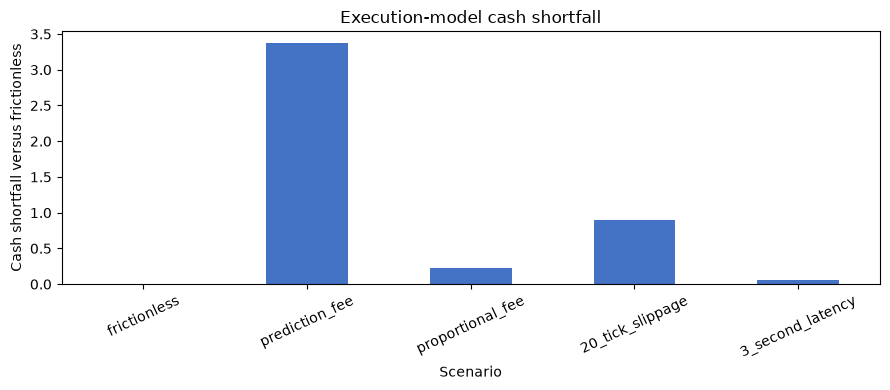

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
active_comparison["cash_shortfall_vs_control"].plot.bar(ax=ax, color="#4472C4")
ax.set_title("Execution-model cash shortfall")
ax.set_xlabel("Scenario")
ax.set_ylabel("Cash shortfall versus frictionless")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()

## Takeaways

- Change one execution assumption at a time against a pinned tape.
- Report implementation shortfall relative to a clearly labelled control.
- Use market orders to study active frictions and limit orders to study queues.
- Queue position requires prints with trustworthy aggressor classification.
- Treat sensitivity across plausible models as model risk, not as error bars.

In [10]:
db.close()